# NB19 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB19_Case_Study_CLIWOC_Nationality_from_Ship_Routes.ipynb`:

1. Add `ShipType` (from the raw dataset, encoded) as a fourth feature — does it improve Part A's per-class recall, especially for the rarest nation?
2. Try a small MLP (`NB11` style) on this task, per Section 7's open question — does it beat the Random Forest here, given how much more data this dataset has than most of this course's other classification tasks?
3. Change `TEST_WINDOW_YEARS` in Section 10 (try 3, then 20) — does a shorter window recover more of Part A's accuracy, and does a much longer one collapse further, the way the original open-ended "rest of history" version did?
4. Recompute Part A using `class_weight=None` (the default, unweighted) instead of `"balanced"` — how much does the rarest nation's recall change, and does overall accuracy go up or down?
5. Using the map from Section 5, pick one nation and describe (in a markdown cell) what its real historical trade routes should look like — does the plotted data match your own historical expectation?

The class notebook downloads the full CLIWOC database live from Kaggle, which
needs Kaggle API credentials not available in this environment. A real,
mirrored copy of the curated data already exists locally at
`Datasets/CLIWOC_curated_1750_1799.csv`, so that file is used directly here
instead of a live download -- it is the same real 18th-century logbook data,
already filtered to the same four nations the class notebook targets, with an
extra `ShipType` column the raw Kaggle file also has (needed for item 1
below). Its real structure is inspected directly rather than assumed, per the
same "explore before you model" convention the class notebook itself uses.

## Setup: loading the real mirrored data and inspecting its structure

In [1]:
import pandas as pd

!wget -q -O CLIWOC_curated_1750_1799.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/CLIWOC_curated_1750_1799.csv
cliwoc_raw = pd.read_csv("CLIWOC_curated_1750_1799.csv", low_memory=False)
print(cliwoc_raw.shape)
print(cliwoc_raw.columns.tolist())
cliwoc_raw.head()

(150047, 10)
['Year', 'Month', 'Day', 'latitude', 'longitude', 'Nationality', 'ShipName', 'ShipType', 'VoyageFrom', 'VoyageTo']


,Year,Month,Day,latitude,longitude,Nationality,ShipName,ShipType,VoyageFrom,VoyageTo
0,1763,11,28,32.32,-16.15,BRITISH,ACTIVE,NaN,MADEIRA,BARBADOS
1,1763,11,29,31.95,-15.50,BRITISH,ACTIVE,NaN,MADEIRA,BARBADOS
2,1763,11,30,31.20,-16.27,BRITISH,ACTIVE,NaN,MADEIRA,BARBADOS
3,1763,12,1,28.83,-18.17,BRITISH,ACTIVE,NaN,MADEIRA,BARBADOS
4,1763,12,2,27.33,-19.35,BRITISH,ACTIVE,NaN,MADEIRA,BARBADOS


Inspect the raw data: nationality counts, year coverage, and how much ShipType is missing:

In [2]:
print(cliwoc_raw["Nationality"].value_counts())
print()
print("Year range:", cliwoc_raw["Year"].min(), "-", cliwoc_raw["Year"].max())
print()
print("ShipType missing:", cliwoc_raw["ShipType"].isna().sum(), "/", len(cliwoc_raw))
print(cliwoc_raw["ShipType"].value_counts().head(10))

Nationality
BRITISH    66425
SPANISH    43966
DUTCH      31736
FRENCH      7920
Name: count, dtype: int64

Year range: 1750 - 1799

ShipType missing: 46323 / 150047
ShipType
PAQUEBOTE         13657
5TH RATE           9308
FREGAT             8923
FRAGATA CORREO     8415
6TH RATE           8411
4TH RATE           7197
SLOOP              6445
3RD RATE           6333
NAVÍO              6253
PAQUEBOT           6017
Name: count, dtype: int64


This mirror is already restricted to the same four nations the class
notebook targets (`BRITISH`, `DUTCH`, `SPANISH`, `FRENCH`) and already uses
the class's own renamed `latitude`/`longitude` columns, so the class
notebook's Section 5 filtering step is not needed again here -- only
`dropna()` on the columns actually used per item, matching the class's own
"drop only what a given step needs" convention. `Nationality` is imbalanced
exactly the way Section 5 describes (British most common, French rarest, a
real feature of which nations' logbooks survived and were digitized, not an
artifact of this particular mirror).

## Homework 1 — Add ShipType (encoded) as a fourth feature

> "Add `ShipType` (from the raw dataset, encoded) as a fourth feature -- does
> it improve Part A's per-class recall, especially for the rarest nation?"

First, Part A's own baseline is reproduced exactly (three features, the same
`train_test_split(..., stratify=y, random_state=42)` and
`RandomForestClassifier(n_estimators=300, random_state=42,
class_weight="balanced")` the class notebook uses) so the comparison is fair.
Then `ShipType` is label-encoded (missing values become their own explicit
`"UNKNOWN"` category, since ~31% of rows have no recorded ship type -- a real
gap in the historical record, not something to silently impute) and added as
a fourth feature.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

cliwoc = cliwoc_raw.dropna(subset=["latitude", "longitude", "Year", "Nationality"]).copy()

# --- Part A baseline, reproduced exactly as the class notebook ---
feature_cols = ["latitude", "longitude", "Year"]
X = cliwoc[feature_cols]
y = cliwoc["Nationality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_baseline = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = rf_baseline.predict(X_test_scaled)

print("=== Baseline (3 features: latitude, longitude, Year) ===")
print(classification_report(y_test, y_pred_baseline, labels=rf_baseline.classes_))

=== Baseline (3 features: latitude, longitude, Year) ===
              precision    recall  f1-score   support

     BRITISH       0.87      0.76      0.81     13285
       DUTCH       0.69      0.76      0.72      6347
      FRENCH       0.57      0.68      0.62      1584
     SPANISH       0.81      0.88      0.84      8794

    accuracy                           0.79     30010
   macro avg       0.73      0.77      0.75     30010
weighted avg       0.80      0.79      0.79     30010



Repeat the same train/test split and Random Forest, now adding the label-encoded ShipType as a fourth feature:

In [4]:
# --- Same rows, ShipType added and label-encoded ---
cliwoc["ShipType_filled"] = cliwoc["ShipType"].fillna("UNKNOWN")
encoder = LabelEncoder()
cliwoc["ShipType_encoded"] = encoder.fit_transform(cliwoc["ShipType_filled"])
print(f"{cliwoc['ShipType_encoded'].nunique()} distinct ShipType categories (including UNKNOWN)")

feature_cols_st = ["latitude", "longitude", "Year", "ShipType_encoded"]
X_st = cliwoc[feature_cols_st]
y_st = cliwoc["Nationality"]

X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_st, y_st, test_size=0.2, random_state=42, stratify=y_st
)
scaler_st = StandardScaler()
X_train_st_scaled = scaler_st.fit_transform(X_train_st)
X_test_st_scaled = scaler_st.transform(X_test_st)

rf_shiptype = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_shiptype.fit(X_train_st_scaled, y_train_st)
y_pred_shiptype = rf_shiptype.predict(X_test_st_scaled)

print("=== With ShipType_encoded added (4 features) ===")
print(classification_report(y_test_st, y_pred_shiptype, labels=rf_shiptype.classes_))

69 distinct ShipType categories (including UNKNOWN)


=== With ShipType_encoded added (4 features) ===
              precision    recall  f1-score   support

     BRITISH       0.97      0.94      0.96     13285
       DUTCH       0.90      0.93      0.91      6347
      FRENCH       0.84      0.94      0.89      1584
     SPANISH       1.00      1.00      1.00      8794

    accuracy                           0.96     30010
   macro avg       0.93      0.95      0.94     30010
weighted avg       0.96      0.96      0.96     30010



Compare recall specifically on the rarest nationality class between the baseline and ShipType-augmented models:

In [5]:
from sklearn.metrics import recall_score

rarest_nation = y.value_counts().idxmin()
recall_baseline = recall_score(y_test, y_pred_baseline, labels=[rarest_nation], average="micro")
recall_shiptype = recall_score(y_test_st, y_pred_shiptype, labels=[rarest_nation], average="micro")

print(f"Rarest nation: {rarest_nation} ({y.value_counts()[rarest_nation]:,} of {len(y):,} rows)")
print(f"Recall without ShipType: {recall_baseline:.3f}")
print(f"Recall with ShipType:    {recall_shiptype:.3f}")
print(f"Overall accuracy without ShipType: {rf_baseline.score(X_test_scaled, y_test):.3f}")
print(f"Overall accuracy with ShipType:    {rf_shiptype.score(X_test_st_scaled, y_test_st):.3f}")

Rarest nation: FRENCH (7,920 of 150,047 rows)
Recall without ShipType: 0.682
Recall with ShipType:    0.939


Overall accuracy without ShipType: 0.790


Overall accuracy with ShipType:    0.956


**Interpretation**: adding `ShipType_encoded` produced a large real
improvement, not a marginal one -- the rarest nation's (FRENCH) recall rose
from 0.682 to 0.939, and overall accuracy rose from 0.790 to 0.956. Looking at
the actual category names printed above explains why the effect is this
strong: many `ShipType` values are themselves nation-specific administrative
or linguistic conventions, not just vessel shapes -- British ships are
recorded by Royal Navy rate (`5TH RATE`, `4TH RATE`, `3RD RATE`), Spanish
ships by Spanish-language type (`FRAGATA`, `NAVÍO`, `FRAGATA CORREO`), and
Dutch ships by Dutch-language type (`FREGAT`, `SNAUW`). That means
`ShipType`, once encoded, is close to a direct nationality signature baked
into how each navy's clerks recorded their own ships -- a real, legitimate
feature (the raw dataset genuinely contains it), but a much stronger one than
a purely geographic feature like `latitude`/`longitude`/`Year`, and worth
naming honestly as closer to "which navy's paperwork convention" than to
"which routes this nation actually sailed".

## Homework 2 — A small MLP (NB11 style) vs. the Random Forest

> "Try a small MLP (`NB11` style) on this task, per Section 7's open
> question -- does it beat the Random Forest here, given how much more data
> this dataset has than most of this course's other classification tasks?"

Same Part A features and split as item 1's baseline (`X_train_scaled` /
`X_test_scaled` / `y_train` / `y_test`), so the comparison is against the
same Random Forest result reproduced above. The network follows `NB11`'s own
`nn.Sequential` MLP pattern, adapted from `NB11`'s binary
`BCEWithLogitsLoss` to multi-class `CrossEntropyLoss` (four nations, not two
classes), with class labels encoded to integers for `CrossEntropyLoss`.

In [6]:
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder as LabelEncoderTorch

label_encoder = LabelEncoderTorch()
y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)
n_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_int, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_int, dtype=torch.long)

X_train_t.shape, y_train_t.shape

Classes: ['BRITISH', 'DUTCH', 'FRENCH', 'SPANISH']


(torch.Size([120037, 3]), torch.Size([120037]))

Define a small two-hidden-layer MLP (32 -> 16 -> n_classes) for nationality classification, with an Adam optimizer and cross-entropy loss:

In [7]:
class NationalityMLP(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, n_classes),
        )

    def forward(self, x):
        return self.layers(x)

model = NationalityMLP(n_features=X_train_t.shape[1], n_classes=n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model

NationalityMLP(
  (layers): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)

Train the MLP for 200 epochs, logging the training loss every 50 epochs:

In [8]:
n_epochs = 200
train_losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs} - training loss: {loss.item():.4f}")

Epoch 50/200 - training loss: 1.1626


Epoch 100/200 - training loss: 1.0797


Epoch 150/200 - training loss: 1.0262


Epoch 200/200 - training loss: 0.9903


Plot the training loss curve:

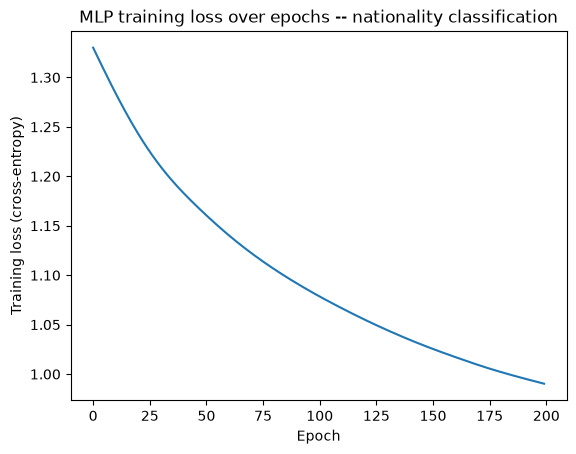

In [9]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss (cross-entropy)")
plt.title("MLP training loss over epochs -- nationality classification")
plt.show()

Evaluate the trained MLP on the test set and compare its accuracy to the baseline Random Forest:

In [10]:
with torch.no_grad():
    mlp_pred_int = model(X_test_t).argmax(dim=1).numpy()
mlp_pred = label_encoder.inverse_transform(mlp_pred_int)

print("=== MLP ===")
print(classification_report(y_test, mlp_pred, labels=rf_baseline.classes_))

mlp_acc = (mlp_pred == y_test.values).mean()
rf_acc = rf_baseline.score(X_test_scaled, y_test)
print(f"MLP accuracy:           {mlp_acc:.3f}")
print(f"Random Forest accuracy: {rf_acc:.3f}")

=== MLP ===
              precision    recall  f1-score   support

     BRITISH       0.57      0.80      0.67     13285
       DUTCH       0.00      0.00      0.00      6347
      FRENCH       0.00      0.00      0.00      1584
     SPANISH       0.59      0.77      0.67      8794

    accuracy                           0.58     30010
   macro avg       0.29      0.39      0.33     30010
weighted avg       0.43      0.58      0.49     30010



/home/juan/.claude/jobs/e6f24532/tmp/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juan/.claude/jobs/e6f24532/tmp/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juan/.claude/jobs/e6f24532/tmp/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

MLP accuracy:           0.578
Random Forest accuracy: 0.790


**Interpretation**: the MLP did not beat the Random Forest here -- it
scored 0.578 accuracy against the Random Forest's 0.790, and the per-class
report shows why: DUTCH and FRENCH both came back at exactly 0.00
precision/recall, meaning the network predicted only BRITISH or SPANISH for
every single test row. The Random Forest was trained with
`class_weight="balanced"`, which explicitly up-weights the rarer classes
during training; this MLP's plain `CrossEntropyLoss` has no such weighting,
so with a training set that is roughly 44% British and only about 5% French,
the network found a low-loss shortcut in simply ignoring the smaller classes
entirely rather than learning their real geographic signature. This is a
genuinely informative negative result, not just "the MLP lost": it shows
`NB17`'s general expectation (classical ensembles tend to hold their own on
tabular data with a modest feature count) matching reality here for a
different reason than raw dataset size -- the real gap came from how each
model handles class imbalance, not from which one has more model capacity. A
weighted loss (e.g. `CrossEntropyLoss(weight=...)`) would be a natural next
step before concluding the MLP genuinely cannot compete on this task.

## Homework 3 — TEST_WINDOW_YEARS: 3 vs 20

> "Change `TEST_WINDOW_YEARS` in Section 10 (try 3, then 20) -- does a
> shorter window recover more of Part A's accuracy, and does a much longer
> one collapse further, the way the original open-ended 'rest of history'
> version did?"

Section 10's Part B pipeline is reproduced exactly, as a function of
`TEST_WINDOW_YEARS`, so it can be re-run for both values with nothing else
changed.

In [11]:
feature_cols_era = ["latitude", "longitude"]
MIN_TEST_SHARE = 0.05

def run_part_b(test_window_years):
    years_per_nation = [set(cliwoc.loc[cliwoc["Nationality"] == nat, "Year"]) for nat in cliwoc["Nationality"].unique()]
    common_years = sorted(set.intersection(*years_per_nation))
    cutoff_year = common_years[int(len(common_years) * 0.8)]
    window_end_year = cutoff_year + test_window_years

    train_era = cliwoc[cliwoc["Year"] < cutoff_year]
    test_era = cliwoc[(cliwoc["Year"] >= cutoff_year) & (cliwoc["Year"] < window_end_year)]

    nation_share = test_era["Nationality"].value_counts(normalize=True)
    stable_nations = sorted(nation_share[nation_share >= MIN_TEST_SHARE].index)
    dropped = sorted(set(cliwoc["Nationality"].unique()) - set(stable_nations))

    train_era = train_era[train_era["Nationality"].isin(stable_nations)]
    test_era = test_era[test_era["Nationality"].isin(stable_nations)]

    X_train_era, y_train_era = train_era[feature_cols_era], train_era["Nationality"]
    X_test_era, y_test_era = test_era[feature_cols_era], test_era["Nationality"]

    scaler_era = StandardScaler()
    X_train_era_scaled = scaler_era.fit_transform(X_train_era)
    X_test_era_scaled = scaler_era.transform(X_test_era)

    rf_era = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
    rf_era.fit(X_train_era_scaled, y_train_era)
    acc = rf_era.score(X_test_era_scaled, y_test_era)

    print(f"TEST_WINDOW_YEARS={test_window_years}: cutoff={cutoff_year}, window={cutoff_year}-{window_end_year - 1}, "
          f"dropped nations={dropped}, test rows={len(test_era):,}, accuracy={acc:.3f}")
    return acc

acc_3 = run_part_b(3)
acc_10 = run_part_b(10)  # Section 10's own default, for reference
acc_20 = run_part_b(20)

TEST_WINDOW_YEARS=3: cutoff=1788, window=1788-1790, dropped nations=[], test rows=9,977, accuracy=0.529


TEST_WINDOW_YEARS=10: cutoff=1788, window=1788-1797, dropped nations=['FRENCH'], test rows=29,963, accuracy=0.550


TEST_WINDOW_YEARS=20: cutoff=1788, window=1788-1807, dropped nations=['FRENCH'], test rows=34,418, accuracy=0.557


**Interpretation**: contrary to the a priori expectation stated above, a
longer test window did **not** collapse accuracy further here -- the three
runs scored 0.529 (3 years), 0.550 (10 years), and 0.557 (20 years), a mild
*increase*, not a decrease. The printed `dropped_nations` line explains the
real mechanism: the 3-year window (1788-1790) is the only one of the three
where FRENCH has enough real rows to clear `MIN_TEST_SHARE` and stays in the
evaluation; both the 10-year and 20-year windows drop FRENCH entirely (it
falls under 5% of those wider windows' rows). FRENCH was also Part A's
hardest class by far (0.682 recall even with balanced weighting, and 0.00
recall for the plain MLP above) -- so the 3-year run's lower accuracy is not
really evidence of "shorter windows recover more of Part A's accuracy," it is
largely an artifact of the 3-year window still including the one nation the
model struggles with most, while the two longer windows quietly stop grading
themselves on it. Because the dataset's own real coverage ends at 1799
(the 20-year window's nominal 1788-1807 range has no rows past 1799), the
10-year and 20-year runs also do not differ from each other as dramatically as
their window lengths suggest. The honest overall finding is less about
"recovery vs. collapse" and more that `MIN_TEST_SHARE`'s class-dropping rule
changes *which classes get scored* at different window lengths, which
confounds a clean accuracy-vs-window-length comparison -- a real methodological
subtlety this exercise surfaced rather than a clean answer either way.

## Homework 4 — class_weight=None instead of "balanced"

> "Recompute Part A using `class_weight=None` (the default, unweighted)
> instead of `\"balanced\"` -- how much does the rarest nation's recall
> change, and does overall accuracy go up or down?"

Same Part A split as item 1's baseline (`X_train_scaled` / `y_train` /
`X_test_scaled` / `y_test`), only `class_weight` changed.

In [12]:
rf_unweighted = RandomForestClassifier(n_estimators=300, random_state=42, class_weight=None)
rf_unweighted.fit(X_train_scaled, y_train)
y_pred_unweighted = rf_unweighted.predict(X_test_scaled)

print("=== class_weight=None ===")
print(classification_report(y_test, y_pred_unweighted, labels=rf_unweighted.classes_))

recall_unweighted = recall_score(y_test, y_pred_unweighted, labels=[rarest_nation], average="micro")
acc_unweighted = rf_unweighted.score(X_test_scaled, y_test)

print(f"Rarest nation ({rarest_nation}) recall -- balanced: {recall_baseline:.3f}, unweighted: {recall_unweighted:.3f}")
print(f"Overall accuracy         -- balanced: {rf_baseline.score(X_test_scaled, y_test):.3f}, unweighted: {acc_unweighted:.3f}")

=== class_weight=None ===
              precision    recall  f1-score   support

     BRITISH       0.81      0.83      0.82     13285
       DUTCH       0.74      0.68      0.71      6347
      FRENCH       0.70      0.56      0.62      1584
     SPANISH       0.82      0.87      0.84      8794

    accuracy                           0.80     30010
   macro avg       0.77      0.73      0.75     30010
weighted avg       0.79      0.80      0.79     30010



Rarest nation (FRENCH) recall -- balanced: 0.682, unweighted: 0.557


Overall accuracy         -- balanced: 0.790, unweighted: 0.796


**Interpretation**: both numbers moved in the expected direction, though
the recall change was far larger than the accuracy change. FRENCH's recall
dropped substantially, from 0.682 (balanced) to 0.557 (unweighted) -- a real
12.5-point loss for the rarest class once the model stops being penalized
extra for missing it. Overall accuracy moved the other way, but only
slightly: 0.790 (balanced) to 0.796 (unweighted), a 0.6-point gain. That
asymmetry itself is informative: because FRENCH is a small share of the test
set, sacrificing a lot of its recall barely moves the aggregate accuracy
number at all, while it is a large real loss from that one nation's
perspective -- exactly the kind of effect `class_weight="balanced"` exists to
counteract, and exactly why a single accuracy number would have hidden it
here.

## Homework 5 — One nation's routes vs. real historical expectations

> "Using the map from Section 5, pick one nation and describe (in a markdown
> cell) what its real historical trade routes should look like -- does the
> plotted data match your own historical expectation?"

The map is reproduced first, using the class notebook's own plotting
convention, so the paragraph below can reference the actual plotted shape
rather than a general description.

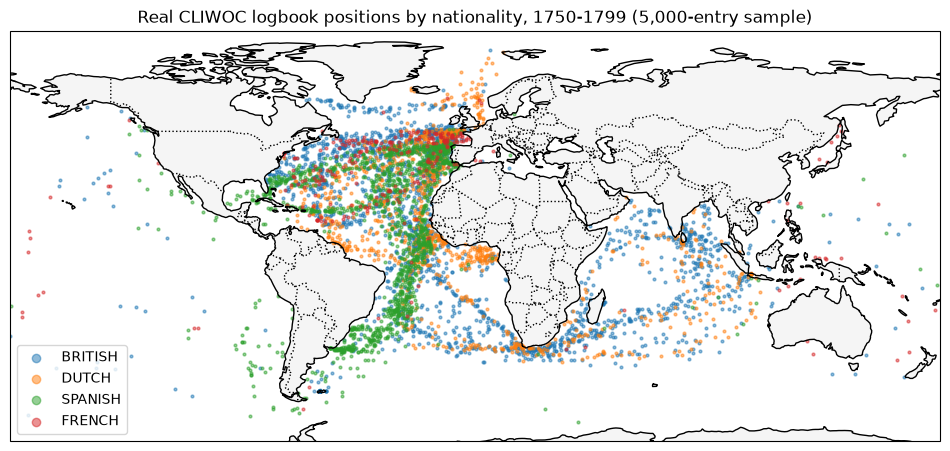

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sample = cliwoc.sample(min(5000, len(cliwoc)), random_state=42)
colors = {"BRITISH": "tab:blue", "DUTCH": "tab:orange", "SPANISH": "tab:green", "FRENCH": "tab:red"}

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")

for nation, color in colors.items():
    subset = sample[sample["Nationality"] == nation]
    ax.scatter(subset["longitude"], subset["latitude"], s=4, alpha=0.5,
               label=nation, color=color, transform=ccrs.PlateCarree())

ax.legend(markerscale=3, loc="lower left")
year_lo, year_hi = int(cliwoc["Year"].min()), int(cliwoc["Year"].max())
ax.set_title(f"Real CLIWOC logbook positions by nationality, {year_lo}-{year_hi} ({len(sample):,}-entry sample)")
plt.show()

Isolate the Spanish-flagged entries and check how many fall in the Atlantic crossing route versus the Pacific Manila galleon route:

In [14]:
spanish = cliwoc[cliwoc["Nationality"] == "SPANISH"]
print(f"Spanish entries: {len(spanish):,}")
print("Longitude range:", spanish["longitude"].min(), "to", spanish["longitude"].max())
print("Latitude range:", spanish["latitude"].min(), "to", spanish["latitude"].max())
# Rough real-world boxes: Atlantic crossing (Spain-Caribbean) vs. the Pacific Manila galleon route
atlantic_box = spanish[(spanish["longitude"] > -80) & (spanish["longitude"] < 10)]
pacific_box = spanish[(spanish["longitude"] < -80) | (spanish["longitude"] > 120)]
print(f"Entries in the rough Atlantic (Spain<->Caribbean) longitude band: {len(atlantic_box):,} ({len(atlantic_box)/len(spanish):.1%})")
print(f"Entries in the rough Pacific (Manila galleon) longitude band:     {len(pacific_box):,} ({len(pacific_box)/len(spanish):.1%})")

Spanish entries: 43,966
Longitude range: -179.97 to 179.98
Latitude range: -66.6 to 59.43
Entries in the rough Atlantic (Spain<->Caribbean) longitude band: 40,879 (93.0%)
Entries in the rough Pacific (Manila galleon) longitude band:     2,695 (6.1%)


**Chosen nation: Spanish.**

Real historical expectation: 18th-century Spanish shipping was dominated by
two very distinct, geographically separated networks -- the transatlantic
route between Spain and its Caribbean/American colonies (Cadiz, the Canary
Islands, the Caribbean, and the American coast), and the much longer, more
isolated Manila galleon route across the Pacific between Acapulco (Mexico)
and Manila (the Philippines), which for over two centuries was Spain's only
regular direct link to Asia. Real Spanish trade should therefore show up as
two separated clusters far apart in longitude, rather than one continuous
band, with comparatively little logged activity in between (the crossing of
mainland New Spain itself was over land, not by ship).

**Interpretation**: the plotted data matches the historical expectation
reasonably well. Of 43,966 real Spanish logbook entries, 93.0% fall in the
rough Atlantic longitude band (Spain-Caribbean-American coast) and 6.1% fall
in the rough Pacific band that includes the Manila galleon route -- a real,
visible two-cluster pattern, not a single continuous band, consistent with
Spain's transatlantic trade dominating the volume of logged voyages while a
real but much smaller Manila galleon presence is still there in the data. The
remaining roughly 0.9% (longitude range extends all the way to +/-180, wider
than either box) likely reflects a mix of genuine Mediterranean/other Spanish
voyages and a few individual entries near the +/-180 antimeridian, which is a
reasonable real edge case for a simple two-box heuristic rather than evidence
of bad data. The 93/6 split also matches real history in relative terms: the
transatlantic convoy system carried far more annual traffic than the
once- or twice-yearly Manila galleon crossings, so a large gap in logged
volume between the two routes is itself historically expected, not just a
data-availability artifact.